---
date: "2026-04-26"
date-modified: last-modified
format:
  html:
    toc: true
---

# Relative Topology and Inheritance

## 1. The Relativity of Topology
If a set $S$ is contained in a [metric subspace](metric-spaces.ipynb) $N \subset M$, saying "$S$ is [open](metric-space-topology.ipynb)" is dangerously ambiguous. Is it open relative to the smaller world $N$, or the larger universe $M$?

**Example:**
Consider the set of rational numbers $S = \{x \in \mathbb{Q} : -\pi < x < \pi\}$.
Let our metric subspace be $N = \mathbb{Q}$ and our parent space be $M = \mathbb{R}$.

* $S$ is **clopen** (both open and closed) with respect to the smaller space $\mathbb{Q}$ (because the boundaries $\pm \pi$ do not exist in $\mathbb{Q}$, so no sequence of rationals can converge out of the set).
* $S$ is **neither** open nor closed with respect to the larger space $\mathbb{R}$ (it contains "gaps" of irrational numbers, so it can't contain an open real ball, and it doesn't contain its real limit points $\pm \pi$).

To resolve this, we use the **Inheritance Principle**, which precisely links the topology of a subspace $N$ to its parent space $M$.

---

## 2. The Inheritance Principle (Open Sets)

**Theorem:** Every metric subspace $N$ of $M$ *inherits* its topology from $M$. Specifically, a subset $V \subset N$ is open in $N$ if and only if it is the intersection of $N$ with some set $U$ that is open in $M$.
$$V \text{ is open in } N \iff V = N \cap U \quad (\text{for some } U \text{ open in } M)$$

**The Core Visual Proof:**
The entire proof boils down to how neighborhoods (open balls) behave when restricted to a subspace. 
Let $N_r p$ be an open ball strictly in the subspace $N$, and $M_r p$ be an open ball in the parent space $M$. By definition of the metric:
$$N_r p = N \cap M_r p$$

Since an open set in $N$ is just a union of $N_r p$ neighborhoods, and each of those is just $N$ intersected with an $M_r p$ neighborhood, the open sets themselves are just $N$ intersected with open sets of $M$. $\square$

### Visualization 1: The Geometry of Inheritance
Run this script to visualize why $N_r p = N \cap M_r p$. If the parent space $M$ is a 2D plane and the subspace $N$ is a 1D line, an open ball in $M$ (a 2D disk) simply "slices" through $N$ to create an open ball in $N$ (a 1D line segment).



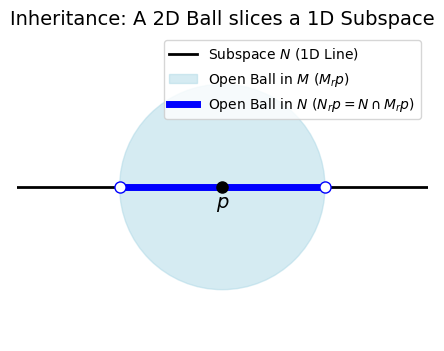

In [1]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(8, 4))

# Parent space M is the 2D plane. Subspace N is the x-axis.
ax.axhline(0, color='black', lw=2, label=r'Subspace $N$ (1D Line)')

# Draw the 2D open ball in M (M_r p)
circle = plt.Circle((0, 0), 2, color='lightblue', alpha=0.5, label=r'Open Ball in $M$ ($M_r p$)')
ax.add_patch(circle)

# Draw the 1D open ball in N (N_r p)
ax.plot([-2, 2], [0, 0], color='blue', lw=5, label=r'Open Ball in $N$ ($N_r p = N \cap M_r p$)')

# Center point p
ax.plot(0, 0, 'ko', markersize=8)
ax.text(0, -0.4, '$p$', fontsize=14, ha='center')

# Boundaries (Open, so we use white circles with blue edges)
ax.plot([-2, 2], [0, 0], 'wo', markeredgecolor='blue', markersize=8)

ax.set_xlim(-4, 4)
ax.set_ylim(-3, 3)
ax.set_aspect('equal')
ax.axis('off')
ax.legend(loc='upper right')
ax.set_title("Inheritance: A 2D Ball slices a 1D Subspace", fontsize=14)

plt.show()

---

## 3. The Danger of "Iff" (Counterexample)

You might be tempted to think: *"If $V$ is open in $N$, then $V$ is open in $M$."* **This is FALSE.** A set can be perfectly open in a subspace, but wildly fail to be open in the parent space.

**Counterexample:**
Let $M = \mathbb{R}$ (the real line) and let our subspace be the closed interval $N = [0, 1]$.
Let $V = [0, 0.5)$.

1.  **Is $V$ open in $N$?** **YES.** By the Inheritance Principle, $V = N \cap U$. If we choose $U = (-0.1, 0.5)$ (which is clearly open in $\mathbb{R}$), then $[0, 1] \cap (-0.1, 0.5) = [0, 0.5) = V$. Therefore, $V$ is open in $N$. Relative to the universe of $[0,1]$, the point $0$ is the "edge of the world"; you don't need wiggle room to the left because the left doesn't exist!
2.  **Is $V$ open in $M$?** **NO.**
    In the universe of $\mathbb{R}$, the point $0$ requires a neighborhood (wiggle room) in all directions. Any open ball around $0$ in $\mathbb{R}$ must include negative numbers. But $V$ contains no negative numbers. Thus, it is not open in $\mathbb{R}$.

### Visualization 2: The Counterexample



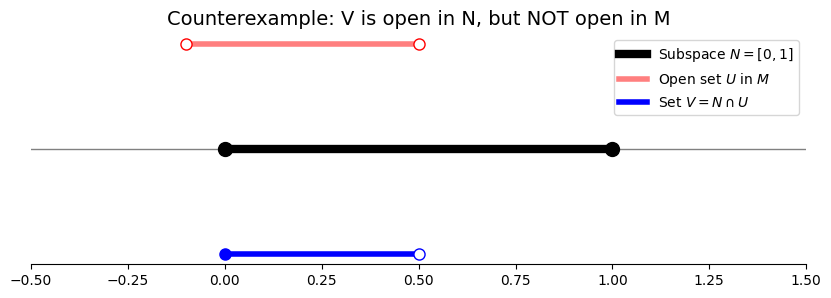

In [2]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 3))

# Draw the parent space M (Real Line)
ax.axhline(0, color='gray', lw=1, zorder=1)

# Draw subspace N = [0, 1]
ax.plot([0, 1], [0, 0], color='black', lw=6, label=r'Subspace $N = [0, 1]$', zorder=2)
ax.plot([0, 1], [0, 0], 'ko', markersize=10, zorder=3) # Solid endpoints

# Draw U = (-0.1, 0.5)
ax.plot([-0.1, 0.5], [0.1, 0.1], color='red', lw=4, alpha=0.5, label=r'Open set $U$ in $M$', zorder=4)
ax.plot([-0.1, 0.5], [0.1, 0.1], 'wo', markeredgecolor='red', markersize=8, zorder=5)

# Draw V = [0, 0.5)
ax.plot([0, 0.5], [-0.1, -0.1], color='blue', lw=4, label=r'Set $V = N \cap U$', zorder=4)
ax.plot(0, -0.1, 'bo', markersize=8, zorder=5) # Closed at 0
ax.plot(0.5, -0.1, 'wo', markeredgecolor='blue', markersize=8, zorder=5) # Open at 0.5

ax.set_yticks([])
ax.set_xlim(-0.5, 1.5)
ax.legend(loc='upper right')
ax.set_title("Counterexample: V is open in N, but NOT open in M", fontsize=14)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)

plt.show()

---

## 4. Inheritance of Closed Sets

Just as open sets are inherited via intersection, closed sets are inherited the exact same way.

**Corollary:** Every metric subspace of $M$ inherits its closed sets from $M$. A subset $L \subset N$ is closed in $N$ if and only if there is some closed set $K \subset M$ such that:
$$L = N \cap K$$

**Proof:**
This proof requires exactly two words: *"Take complements."*
If $L$ is closed in $N$, its complement in the subspace ($N \setminus L$) is open in $N$. 
By the Inheritance Principle, $N \setminus L = N \cap U$ for some open set $U \subset M$.
Taking the complement again (relative to $N$) yields $L = N \cap U^c$. 
Since $U$ is open in $M$, its complement $U^c$ is a closed set in $M$. Let $K = U^c$, and we have $L = N \cap K$. $\square$

---

## 5. When does "Iff" actually work?

We proved in the counterexample that "$V$ is open in $N \implies V$ is open in $M$" is generally false. However, it *is* true under one very specific condition: **when the subspace itself is open.**

**Corollary:** 1. If $N$ is an **open** subset of $M$, then a set $V \subset N$ is open in $N$ if and only if it is open in $M$.
2. If $N$ is a **closed** subset of $M$, then a set $L \subset N$ is closed in $N$ if and only if it is closed in $M$.